# Multidimensional quantum Fourier transform for nanosheet material evaluation by electron microscopy: a case of 2D pattern processing

ここでは、[Sampei et al. (2025)](https://pubs.rsc.org/en/content/articlelanding/2025/cp/d4cp04399e)の内容を理解し、その実装を通してQamomileの使い方を学びましょう。

## 電子顕微鏡によるナノシート材料の特性評価のための多次元量子フーリエ変換

### 問題背景

ナノシート材料は、幅広い化学応用のために注目を集めています。
その物理化学的な特性は、その厚さに応じて劇的に変化します。
そのため、ナノシート材料の多様な特性を自在に制御するには、厚さを制御した合成や、ナノシート材料の層数の特定が極めて重要となります。
総数を特定する有望な手段として、透過型電子顕微鏡 (TEM) による観測があります。
TEM を用いた観測からは、透過イメージと Selected Area Electron Diffraction (SAED: 制限視野電子回折) パターンの両方が得られます。
そこで、次世代コンピューティング技術を活用したナノシート材料の SAED パターンのシミュレーションが、極めて有望なアプローチとして注目され始めました。
この論文では、多次元量子フーリエ変換 (QFT) の応用可能性を探求し、その利用可能な入力データをより詳細に特性評価することを目的として、QFTを用いた $\mathrm{CeO_2}$ ナノシートの近似的な SAED パターンのシミュレーションを行いました。

### 先行研究

QFT は、Shor のアルゴリズムや量子位相推定のコア技術としてよく知られています。
この QFT の重要な改良手法として、[Pfeffer 2023](https://arxiv.org/abs/2301.13835) が挙げられます。
この研究では、既知の QFT 回路をベースに、多次元 QFT を実現する効率的な回路を導出しました。

![](qft_for_nanosheet_material_01.png)  
[Pfeffer (2023)](https://arxiv.org/abs/2301.13835)より。  

Pfeffer は古典的な行・列分解にヒントを得て、$d$ 次元配列に対して $d$ 個の1次元 QFT をテンソル積構造で並列実行することで、$M=(2^n)^d$ の配列に対して $\mathcal{O} (\log^2 (M)/d)$ の計算量を達成しました。
しかしこの手法は、各次元サイズが $N_i = 2^{n_i}$ でなければならないという制限がありました。
そこで、[Sampei et al. (2025)](https://pubs.rsc.org/en/content/articlelanding/2025/cp/d4cp04399e)ではこの制限を解消する手法を提案しました。

### 任意の周期性をもつ多次元入力のための QFT

結晶やナノシートの実空間構造は、2のべき乗の格子点数を持つとは限りません。
実際の結晶格子は、任意の整数比の周期構造を持ちます。
そこで、[Sampei et al. (2025)](https://pubs.rsc.org/en/content/articlelanding/2025/cp/d4cp04399e)では、結晶の周期性をそのまま量子状態に符号化するための、前処理手法を提案しました。

#### 領域の切り捨て/ゼロ埋め

実際に得られる結晶構造のデータは、2のべき乗であるとは限りません。
実際の周期が $2^p$ より長い場合、最初の $2^p$ の点のみを抜き出すことで、QFTを適用可能にします。
また実際の周期が $2^p$ より短い場合、その前後にゼロを追加することでも、QFTを適用可能にします。

#### フラットトップ窓関数の適用

領域の切り捨て/ゼロ埋めの適用だけでは、スペクトルのサイドローブが発生します。
そこでこれを抑えるために、切り捨て/ゼロ埋めされた入力に窓関数を乗算します。
この論文で用いられている窓関数は、次のような 5-term FD-FT window $w_5(n)$ です。

$$
w_5(n) 
= \sum_{k=0}^4 (-1)^k a_k \cos \left( \frac{2\pi k n}{N}\right) \tag{1}
$$

ここで $(a_0, a_1, a_2, a_3, a_4) = (0.1881, 0.36923, 0.28702, 0.13077, 0.02488)$であり、$N$ は考えている次元方向の点の総数、$n$ はその点の位置 $(n=1, 2, \dots, N)$ を表します。
2次元の場合、$w_5(x) w_5(y)$ のような積を、入力に掛け合わせます。

## 実装

### 多次元QFT

Qamomileを用いて、多次元QFTのための量子回路を実装しましょう。
ここで用いる量子ビット数は、$x$方向に3量子ビットと$y$方向に3量子ビットの、計6量子ビットとします。

In [1]:
import qamomile.circuit as qmc
from qamomile.circuit.frontend.handle import Vector
from qamomile.circuit.stdlib.qft import QFT
from qamomile.circuit.algorithm import amplitude_encoding

Nqx = 3
Nqy = 3

def apply_partial_qft(qubits, start, length):
    qft_gate = QFT(length)
    qubit_args = [qubits[start+i] for i in range(length)]
    result = qft_gate(*qubit_args)
    for i in range(length):
        qubits[start+i] = result[i]
    return qubits

@qmc.qkernel
def qft_for_multidimension(inputs: qmc.Vector[qmc.Float]) -> qmc.Vector[qmc.Bit]:
    N = Nqx + Nqy
    q = qmc.qubit_array(N, name="q")
    q = amplitude_encoding(q, inputs)  
    q = apply_partial_qft(q, start=0, length=Nqx)
    q = apply_partial_qft(q, start=Nqx, length=Nqy)
    return qmc.measure(q)

### 入力の作成

続いて、入力データを作成しましょう。
ここでは、次のような仮想的な周期データを用いることにします。

In [2]:
import numpy as np

Nx = 6
Ny = 6
xs = np.arange(Nx)
ys = np.arange(Ny)
X, Y = np.meshgrid(xs, ys, indexing="ij")
f = np.cos(np.pi * X / 2) * np.cos(np.pi * Y / 2)

作成された入力データは、次のような単純な周期性を持つ2次元データです。

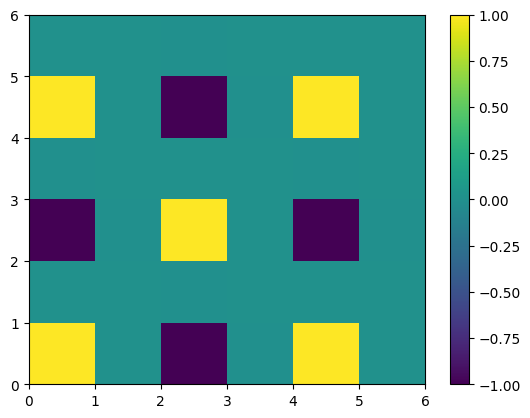

In [3]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

im1 = plt.pcolormesh(f, cmap="viridis")
plt.colorbar(im1)
plt.show()

このデータはサイズが2のべき乗でないために、そのままでは実装されたQFTを適用することができません。
そこでゼロ埋めを施すことで、サイズを2のべき乗に拡張しましょう。

In [4]:
def padding_array(array_2d: np.ndarray, num_x_target: int, num_y_target: int) -> np.ndarray:
    num_x, num_y = array_2d.shape
    pad_width_x = num_x_target - num_x
    pad_width_y = num_y_target - num_y
    pad_x_left = int(np.ceil(pad_width_x / 2.0))
    pad_x_right = int(np.floor(pad_width_x / 2.0))
    pad_y_left = int(np.ceil(pad_width_y / 2.0))
    pad_y_right = int(np.floor(pad_width_y / 2.0))
    array_2d_padding = np.pad(array_2d, ((pad_x_left, pad_x_right), (pad_y_left, pad_y_right)))
    return array_2d_padding

Nx_target = 2 ** Nqx
Ny_target = 2 ** Nqy
f_padding = padding_array(f, Nx_target, Ny_target)

ゼロ埋めされたデータを見てみましょう。

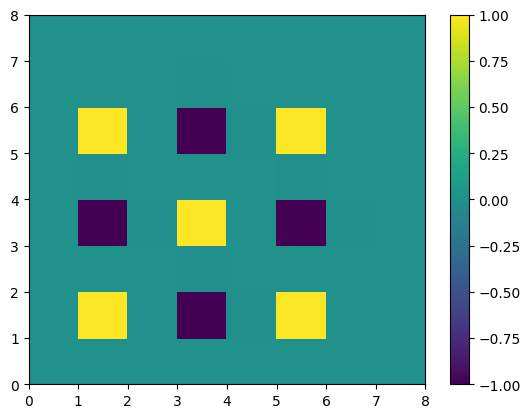

In [5]:
im2 = plt.pcolor(f_padding, cmap="viridis")
plt.colorbar(im2)
plt.show()

これでQFTの適用が可能になりました。

### ゼロ埋め結果の実行

先ほどのゼロ埋めされた入力に、2次元QFTを適用しましょう。

In [6]:
from qamomile.qiskit import QiskitTranspiler

f_flatten = f_padding.flatten()
transpiler = QiskitTranspiler()
exe = transpiler.transpile(qft_for_multidimension, bindings={"inputs": f_flatten})
result1 = exe.sample(transpiler.executor(), shots=2**14).result()

得られた結果を、2次元波数空間における確率にマッピングしましょう。

In [7]:
def compute_prob(result: qmc.transpiler.job.SampleResult) -> np.ndarray:
    prob = np.zeros(f_padding.shape)
    total = sum(c for _, c in result.results)
    for bits, count in result.results:
        kx = sum([2 ** i * bits[i] for i in range(Nqx)])
        ky = sum([2 ** i * bits[i+Nqx] for i in range(Nqy)])
        prob[kx, ky] += count / total
    return prob

prob = compute_prob(result1)

比較のため、古典FFTの結果も計算します。

In [8]:
def compute_classical_fft(f: np.ndarray) -> np.ndarray:
    Nx_target, Ny_target = f.shape
    f_normalized = f / np.linalg.norm(f)
    fft = np.fft.ifft2(f_normalized) * np.sqrt(Nx_target * Ny_target)
    prob = np.abs(fft) ** 2
    return prob

prob_classical = compute_classical_fft(f_padding)

結果を可視化しましょう。

<Figure size 1400x600 with 0 Axes>

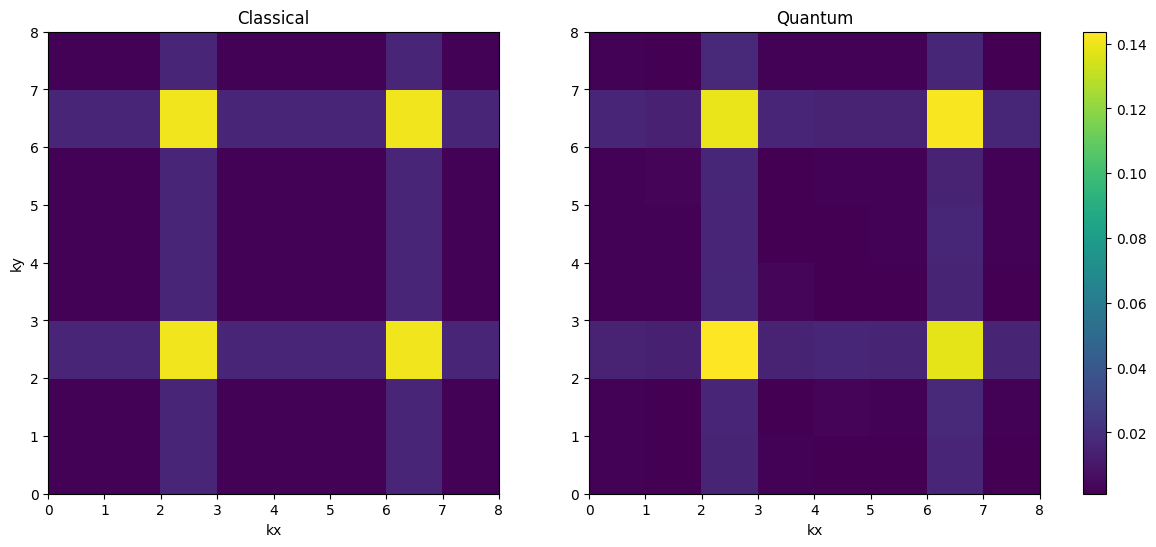

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 6))
vmin = min(prob_classical.min(), prob.min())
vmax = max(prob_classical.max(), prob.max())
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im3 = axes[0].pcolor(prob_classical, vmin=vmin, vmax=vmax, cmap="viridis")
axes[0].set_title("Classical")
axes[0].set_xlabel("kx")
axes[0].set_ylabel("ky")
im4 = axes[1].pcolor(prob, vmin=vmin, vmax=vmax, cmap="viridis")
axes[1].set_title("Quantum")
axes[1].set_xlabel("kx")
# 両プロットで共通の 1 本のカラーバー
fig.colorbar(im4, ax=axes, fraction=0.046, pad=0.04)
plt.show()

古典手法でも量子手法でも、同様のサイドローブが見られていることがわかります。

### 窓関数の実装

続いてはサイドローブを抑えるために、窓関数の実装を行いましょう。

In [10]:
def w5(N: int) -> np.ndarray:
    a = np.array([0.1881, 0.36923, 0.28702, 0.13077, 0.02488])
    n = np.arange(N)
    results = [(-1) ** k * a[k] * np.cos(2 * np.pi * k * n / N) for k in range(5)]
    return sum(results)

wx = w5(Nx_target)
wy = w5(Ny_target)
w2d = wx[:, None] * wy[None, :]

窓関数の概形を描画してみましょう。

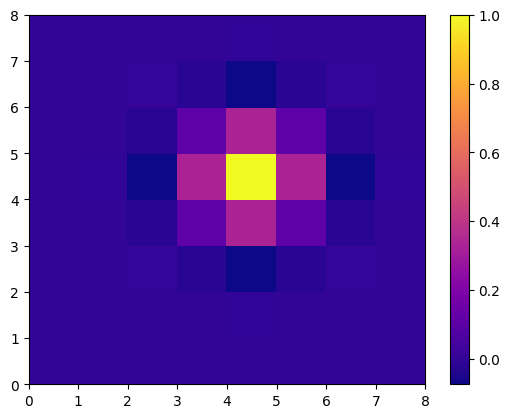

In [11]:
w2dmin = np.min(w2d)
w2dmax = np.max(w2d)
im5 = plt.pcolor(w2d, cmap="plasma")
plt.colorbar(im5)
plt.show()

サイドローブを抑えるために、中心領域のみを切り出しつつ、ゆっくりと減衰するような広がった概形になっていることがわかります。
この窓関数をゼロ埋めされたデータに適用し、2次元QFTを実行しましょう。

In [12]:
fw = w2d * f_padding
fw_flatten = fw.flatten()
exe = transpiler.transpile(qft_for_multidimension, bindings={"inputs": fw_flatten})
result2 = exe.sample(transpiler.executor(), shots=2**14).result()

先ほどと同様に、得られた結果を波数空間にマッピングしましょう。

In [13]:
prob2 = compute_prob(result2)

また比較のため、同じく窓関数を適用した入力に古典FFTを適用しましょう。

In [14]:
prob_classical2 = compute_classical_fft(fw)

これら2つの結果を可視化しましょう。

<Figure size 1400x600 with 0 Axes>

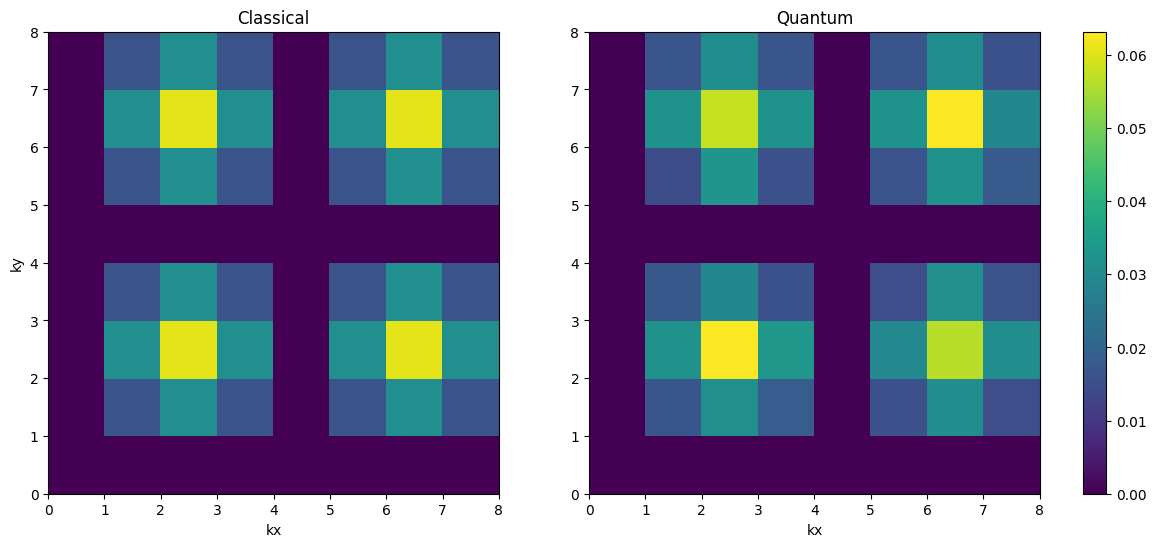

In [15]:
fig = plt.figure(figsize=(14, 6))
vmin = min(prob_classical2.min(), prob2.min())
vmax = max(prob_classical2.max(), prob2.max())
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im6 = axes[0].pcolor(prob_classical2, vmin=vmin, vmax=vmax, cmap="viridis")
axes[0].set_title("Classical")
axes[0].set_xlabel("kx")
axes[0].set_ylabel("ky")
im7 = axes[1].pcolor(prob2, vmin=vmin, vmax=vmax, cmap="viridis")
axes[1].set_title("Quantum")
axes[1].set_xlabel("kx")
fig.colorbar(im7, ax=axes, fraction=0.046, pad=0.04)
plt.show()

窓関数を導入することで、ピークの値は下がっているものの、サイドローブの範囲が局在化していることがわかります。

## 参考文献

[1] [Sampei et al., 2025, "Multidimensiona quantum Fourier transform for nanosheet material evolution by electron microscopy: a case of 2D pattern processing"](https://pubs.rsc.org/en/content/articlelanding/2025/cp/d4cp04399e)  
[2] [Pfeffer, 2023, "Multidimensional Quantum Fourier Transformation"](https://arxiv.org/abs/2301.13835)  